In [1]:
# 08/2025
###########################################################################################
# exploratory data analysis using the data loaded 
#   Test correlation among shape descriptors
#   Specific boxplots for figures or comparisons
#	Scatterplots: predictor vs. outcome → rough check for linearity
#	General Boxplots: for categorical predictors → group distributions
#	Identify obvious outliers or impossible values
#	Check if predictors are correlated (multicollinearity risk)

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [3]:
curProject = 'amputee'
curRegion = 'CSSyl'  # CSSyl or CSpreCS
curRoot = 'C'  # 'C' or 'D'
curDistType = 'min'     ############################ !!!!!!!!!!!!!!!  CHANGE  !!!!!!!!!!!!!!  ###########################

################################  Read the CSV file into a DataFrame  ################################
#file_path = rf'{curRoot}:\B_projWIP\proj_{curProject}\Analysis_2025\{curRegion}_withMorphometry_{curDistType}_2024.csv'
file_path = rf'{curRoot}:\B_projWIP\proj_{curProject}\Analysis_2025\{curRegion}_withMorphometry_asy_{curDistType}_2024.csv'
#file_path = rf'{curRoot}:\B_projWIP\proj_{curProject}\Analysis_2025\{curRegion}_combined_{curDistType}_2024.csv'
#file_path = rf'{curRoot}:\B_projWIP\proj_{curProject}\Analysis_2025\{curRegion}_combined_{curDistType}_2025.csv'

print(file_path)

merged_info = pd.read_csv(file_path)
print(len(merged_info))
#print("Data types:\n", df_loaded.dtypes)

C:\B_projWIP\proj_amputee\Analysis_2025\CSSyl_withMorphometry_asy_min_2024.csv
130


In [4]:
################################  Data Selection  ################################
left_hem = merged_info[merged_info['Hemisphere'] == 'Left']
right_hem = merged_info[merged_info['Hemisphere'] == 'Right']
controls = merged_info[merged_info['Group'] == 'CTR'] 
congenitals = merged_info[merged_info['Group'] == 'CONG']
amputees = merged_info[merged_info['Group'] == 'AMP']

# DataFrame with missing hemisphere:
missing_hem = merged_info[
    ((merged_info['Hemisphere'] == 'Left') & (merged_info['AmpSide'] == 'R')) |
    ((merged_info['Hemisphere'] == 'Right') & (merged_info['AmpSide'] == 'L'))
]

# DataFrame with using hemisphere:
using_hem = merged_info[
    ((merged_info['Hemisphere'] == 'Left') & (merged_info['AmpSide'] == 'L')) |
    ((merged_info['Hemisphere'] == 'Right') & (merged_info['AmpSide'] == 'R'))
]

# Adding controls
missing_hem_withControl = pd.concat([missing_hem, controls], ignore_index=True)
using_hem_withControl = pd.concat([using_hem, controls], ignore_index=True)

missing_hem_withControl_L = missing_hem_withControl[missing_hem_withControl['Hemisphere'] == 'Left']
missing_hem_withControl_R = missing_hem_withControl[missing_hem_withControl['Hemisphere'] == 'Right']
using_hem_withControl_L = using_hem_withControl[using_hem_withControl['Hemisphere'] == 'Left']
using_hem_withControl_R = using_hem_withControl[using_hem_withControl['Hemisphere'] == 'Right']


# using and missing_hem of only congenitals
missing_hem_onlyCong = congenitals[
    ((congenitals['Hemisphere'] == 'Left') & (congenitals['AmpSide'] == 'R')) |
    ((congenitals['Hemisphere'] == 'Right') & (congenitals['AmpSide'] == 'L'))
]
using_hem_onlyCong = congenitals[
    ((congenitals['Hemisphere'] == 'Left') & (congenitals['AmpSide'] == 'L')) |
    ((congenitals['Hemisphere'] == 'Right') & (congenitals['AmpSide'] == 'R'))
]

In [5]:
col = merged_info['AgeScan']
# Quick summary: count, mean, std, min, quartiles, max
print(col.describe())
print()
col = amputees['duration_amputation']
print(col.describe())

col = congenitals['duration_amputation']
print(col.describe())

col = controls['AgeScan']
print(col.describe())

count    130.000000
mean      42.353846
std       12.127783
min       24.000000
25%       32.000000
50%       42.000000
75%       52.000000
max       70.000000
Name: AgeScan, dtype: float64

count    32.000000
mean     16.687500
std      11.493161
min       1.000000
25%       6.750000
50%      13.000000
75%      26.500000
max      37.000000
Name: duration_amputation, dtype: float64
count    50.000000
mean     41.440000
std      11.263378
min      25.000000
25%      34.000000
50%      38.000000
75%      51.000000
max      63.000000
Name: duration_amputation, dtype: float64
count    48.000000
mean     41.666667
std      12.914339
min      24.000000
25%      30.250000
50%      41.500000
75%      49.750000
max      70.000000
Name: AgeScan, dtype: float64


In [6]:
#print(len(missing_hem_withControl))
col = missing_hem_withControl['UMAP1_U1']

# Quick summary: count, mean, std, min, quartiles, max
print(col.describe())

# Median
print("Median:", col.median())

# Specific quantiles
print("25th percentile (Q1):", col.quantile(0.25))
print("50th percentile (Q2/median):", col.quantile(0.5))
print("75th percentile (Q3):", col.quantile(0.75))

# Mean and standard deviation
print("Mean:", col.mean())
print("Std dev:", col.std())

count    89.000000
mean      2.688515
std       5.976225
min      -7.674470
25%      -2.111303
50%       1.739678
75%       8.173648
max      12.632370
Name: UMAP1_U1, dtype: float64
Median: 1.7396784
25th percentile (Q1): -2.1113033
50th percentile (Q2/median): 1.7396784
75th percentile (Q3): 8.173648
Mean: 2.688514521235955
Std dev: 5.976225421612241


In [7]:
## Verification of subjects in each group, for visualization script ##

print(merged_info.columns)

# Get all SubjName values where Group == 'CONG'
missing_cong_subjnames = missing_hem_withControl.loc[missing_hem_withControl["Group"] == "CONG", "subjName"].tolist()
print(missing_cong_subjnames)
using_cong_subjnames = using_hem_withControl.loc[using_hem_withControl["Group"] == "CONG", "subjName"].tolist()
print(using_cong_subjnames)
print()
missing_amp_subjnames = missing_hem_withControl.loc[missing_hem_withControl["Group"] == "AMP", "subjName"].tolist()
print(missing_amp_subjnames)
using_amp_subjnames = using_hem_withControl.loc[using_hem_withControl["Group"] == "AMP", "subjName"].tolist()
print(using_amp_subjnames)
print()


Index(['subjName', 'surface_talairach', 'surface_native', 'maxdepth_talairach',
       'maxdepth_native', 'meandepth_talairach', 'meandepth_native',
       'hull_junction_length_talairach', 'hull_junction_length_native',
       'GM_thickness', 'opening', 'iso1', 'iso2', 'iso3', 'UMAP1_U1',
       'UMAP1_U2', 'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4', 'SubjID',
       'Study', 'Hemisphere', 'Gender', 'AgeScan', 'AgeLimbLoss', 'Group',
       'AmpSide', 'DominantHand', 'Group_num', 'Gender_function',
       'AmpSide_function', 'birthyear', 'Prosthesisusage', 'Stumpusage',
       'amputatio level', 'Cos', 'Fun', 'Myo', 'missinghand', 'intacthand',
       'residualarm', 'intactarm', 'lips', 'feet', 'missing_hem',
       'duration_amputation', 'surface_talairach_asy',
       'maxdepth_talairach_asy', 'meandepth_talairach_asy',
       'hull_junction_length_talairach_asy', 'GM_thickness_asy', 'opening_asy',
       'iso1_asy', 'UMAP1_U2_asy', 'surface_talairach_LRasy',
       'maxdepth_ta

In [8]:
#############  list of left-handers in controls  ##############
print(merged_info.loc[merged_info['DominantHand'] == 'L', 'SubjID'])

46     PC06
51     PC11
53     PC13
55     PC15
57     PC17
59     PC19
61     PC21
64     PC24
111    PC06
116    PC11
118    PC13
120    PC15
122    PC17
124    PC19
126    PC21
129    PC24
Name: SubjID, dtype: object


In [9]:
############################ !!!!!!!!!!!!!!!  CHANGE  !!!!!!!!!!!!!!  ###########################
# using_hem_withControl, missing_hem_withControl, using_hem, missing_hem, right_hem, left_hem, merged_info, missing_hem_onlyCong,using_hem_onlyCong 
#cur_info = using_hem_onlyCong
cur_info = missing_hem_onlyCong

In [10]:
#######################  investigate possible correlation between shape discriptors  ######################
measure1 = 'iso1'
measure2 = 'UMAP1_U2'

formula = f'{measure1} ~ {measure2} + AgeScan + Gender + Study + Hemisphere'
model = smf.ols(formula, data=cur_info).fit()
print(f'========================= Results for correlation between {measure1} and {measure2} ===========================')
print(model.summary())
print('\n')

========================= Results for correlation between iso1 and UMAP1_U2 ===========================
                            OLS Regression Results                            
Dep. Variable:                   iso1   R-squared:                       0.485
Model:                            OLS   Adj. R-squared:                  0.350
Method:                 Least Squares   F-statistic:                     3.582
Date:                Wed, 12 Nov 2025   Prob (F-statistic):             0.0189
Time:                        12:34:19   Log-Likelihood:                -56.721
No. Observations:                  25   AIC:                             125.4
Df Residuals:                      19   BIC:                             132.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
------------------

In [11]:
import pingouin as pg

# Make a copy to avoid overwriting cur_info
df = cur_info.copy()

# Convert categorical variables to numeric codes
for col in ['Gender', 'Study', 'Hemisphere']:
    if df[col].dtype == 'object' or str(df[col].dtype) == 'category':
        df[col] = df[col].astype('category').cat.codes

pcorr = pg.partial_corr(data=df,
                        x=measure1,
                        y=measure2,
                        covar=['AgeScan', 'Gender', 'Study', 'Hemisphere'],
                        method='pearson')

print(pcorr)


          n        r          CI95%     p-val
pearson  25 -0.29876  [-0.65, 0.15]  0.188327


In [12]:
################################  Exploratory data plots  ################################

C:\Users\joyca\AppData\Local\Temp\ipykernel_1144\1070942496.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\joyca\AppData\Local\Temp\ipykernel_1144\1070942496.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\joyca\AppData\Local\Temp\ipykernel_1144\1070942496.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\joyca\AppData\Local\Temp\ipykernel_1144\1070942496.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

C:\B_projWIP\proj_amputee\Analysis_2025\Plots\iso1_U12_U24_CSSyl_min_congAmpCtr_2024_Box_L_R_Both.png


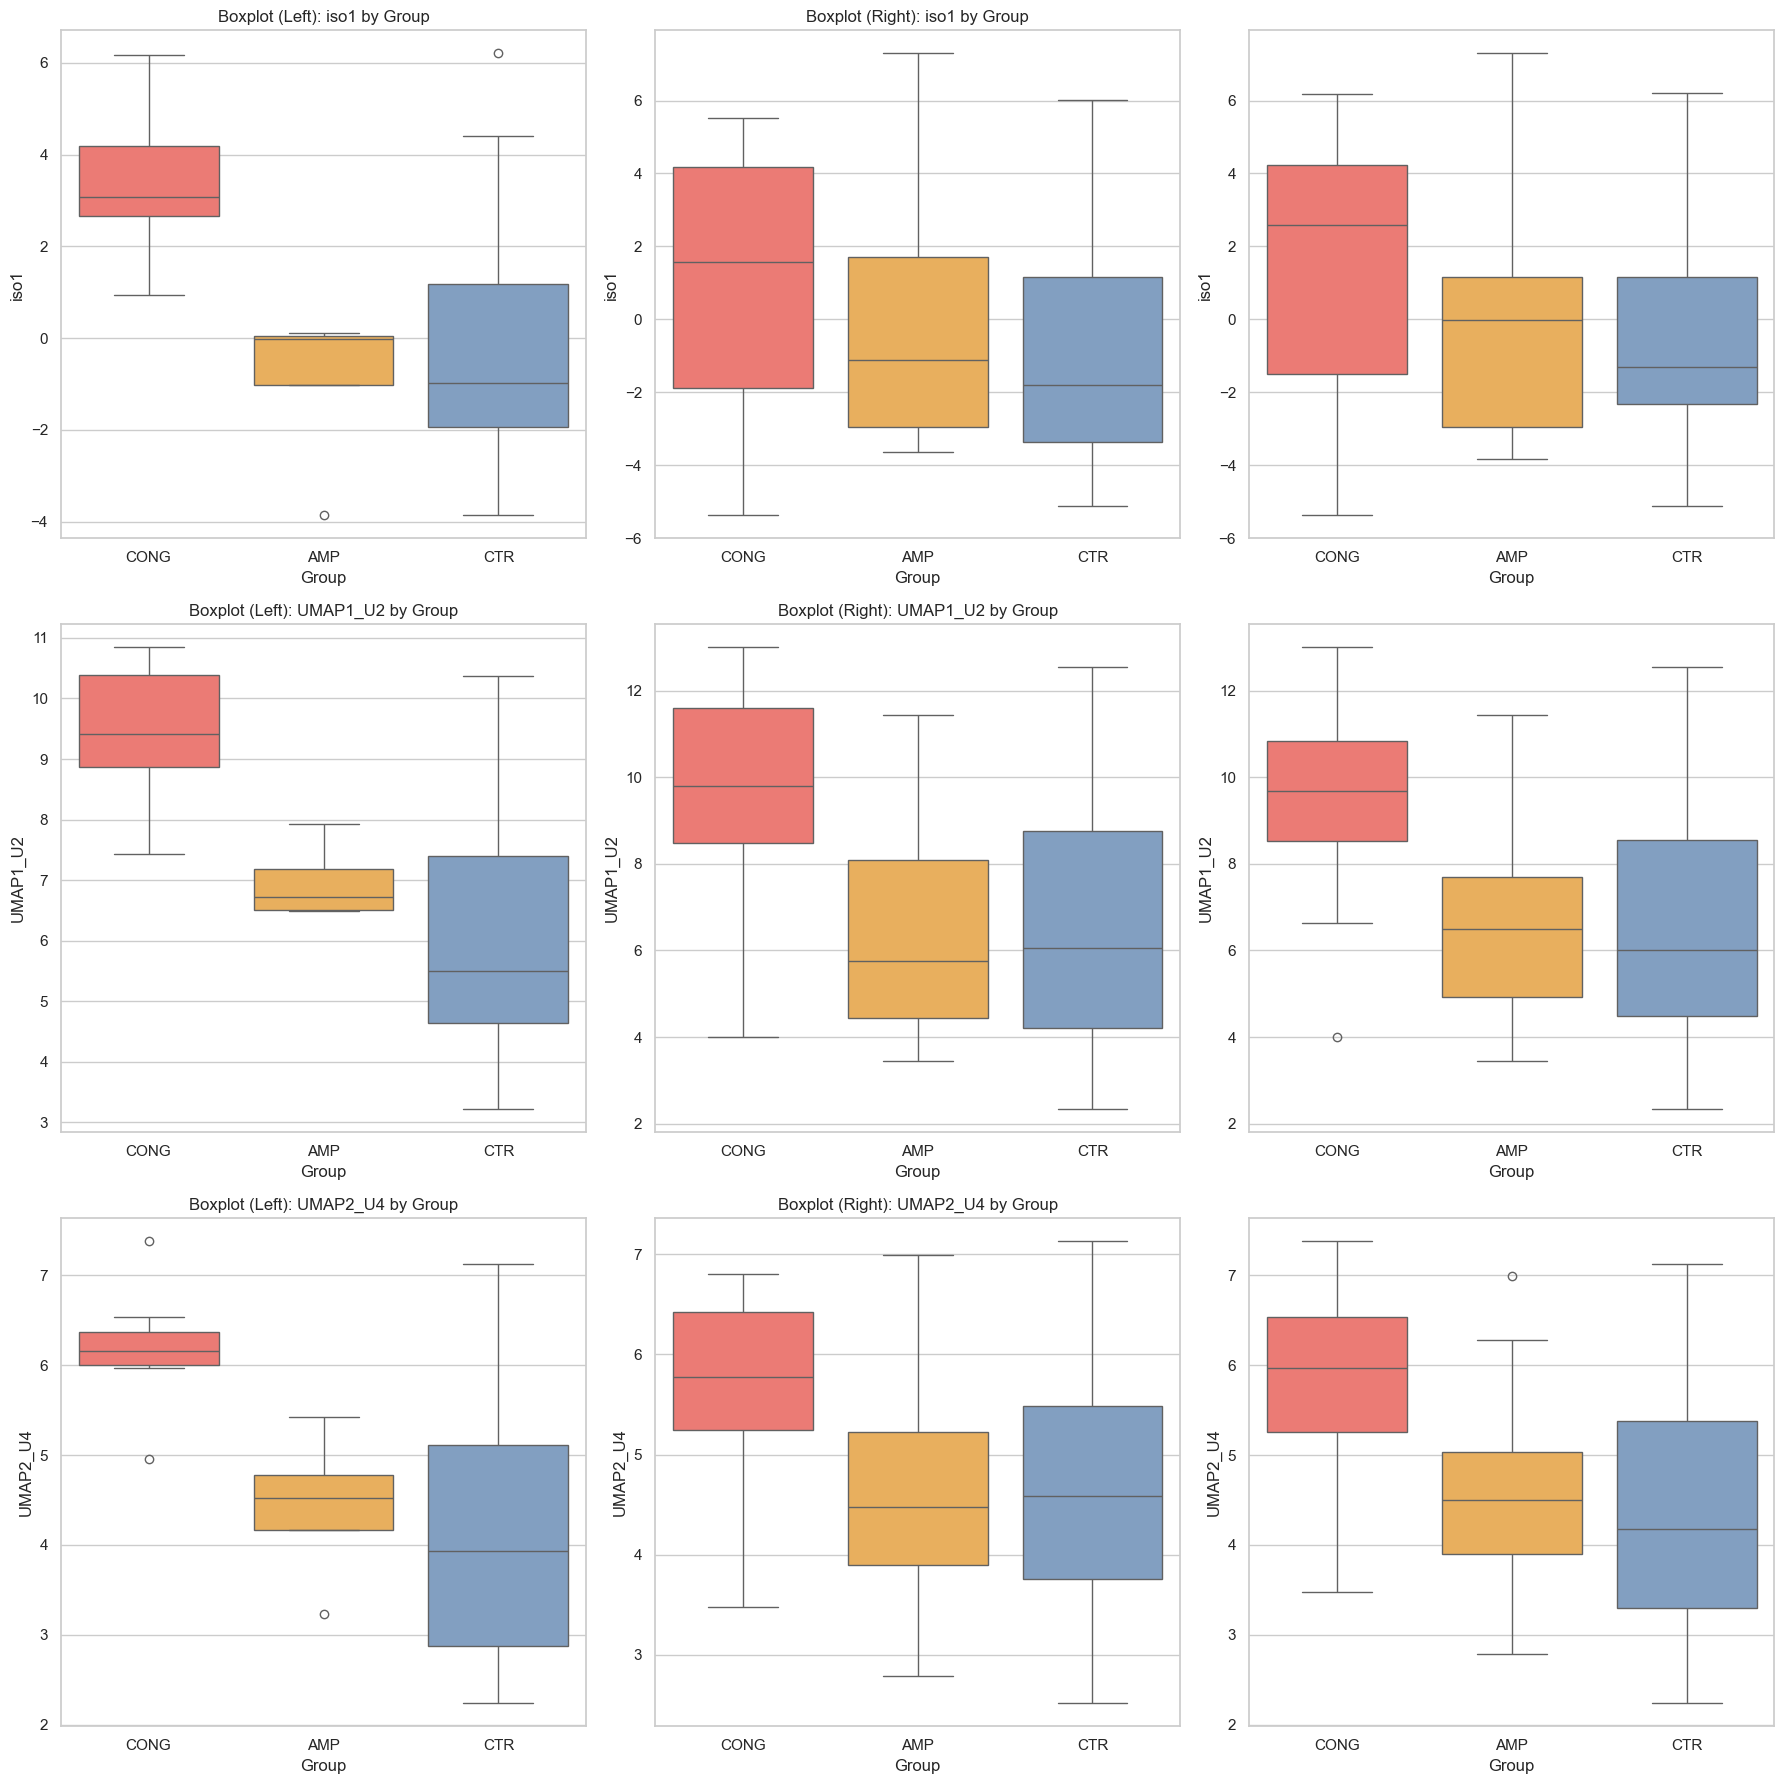

In [13]:
######################  compare 2024 and 2025 data, fix group order and color  ######################
######################  different groups  ####################
# Define group order and color mapping
group_order = ["CONG", "AMP", "CTR"]
#group_colors = {"CONG": "green", "AMP": "orange", "CTR": "blue"}
# Create pastel colors for green, orange, blue
#pastel_colors = sns.color_palette(["#77dd77", "#ffb347", "#779ecb"])  # soft green, soft orange, soft blue
pastel_colors = sns.color_palette(["#ff6961", "#ffb347", "#779ecb"])  # soft red, soft orange, soft blue

group_colors = dict(zip(group_order, pastel_colors))

# Set style
sns.set(style="whitegrid")

# Create figure
fig, axes = plt.subplots(3, 3, figsize=(18, 18))

# List of shape measures
shape_measures = ['iso1', 'UMAP1_U2', 'UMAP2_U4']

# Loop through measures
for i, shape in enumerate(shape_measures):
    # Left hemisphere
    sns.boxplot(
        x="Group", y=shape, data=missing_hem_withControl_L,
        order=group_order, palette=group_colors, ax=axes[i, 0]
    )
    axes[i, 0].set_title(f'Boxplot (Left): {shape} by Group')
    axes[i, 0].set_xlabel("Group")
    axes[i, 0].set_ylabel(shape)

    # Right hemisphere
    sns.boxplot(
        x="Group", y=shape, data=missing_hem_withControl_R,
        order=group_order, palette=group_colors, ax=axes[i, 1]
    )
    axes[i, 1].set_title(f'Boxplot (Right): {shape} by Group')
    axes[i, 1].set_xlabel("Group")
    axes[i, 1].set_ylabel(shape)

    # Both hemisphere
    sns.boxplot(
        x="Group", y=shape, data=missing_hem_withControl,
        order=group_order, palette=group_colors, ax=axes[i, 2]
    )
    axes[i, 1].set_title(f'Boxplot (Right): {shape} by Group')
    axes[i, 1].set_xlabel("Group")
    axes[i, 1].set_ylabel(shape)

# Layout
plt.tight_layout()

measure = 'iso1_U12_U24'
curPlotName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Analysis_2025\Plots\{measure}_{curRegion}_{curDistType}_congAmpCtr_2024_Box_L_R_Both.png'
print(curPlotName)
#plt.savefig(curPlotName)

plt.show()


C:\Users\joyca\AppData\Local\Temp\ipykernel_1144\1141650813.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\joyca\AppData\Local\Temp\ipykernel_1144\1141650813.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\joyca\AppData\Local\Temp\ipykernel_1144\1141650813.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\joyca\AppData\Local\Temp\ipykernel_1144\1141650813.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

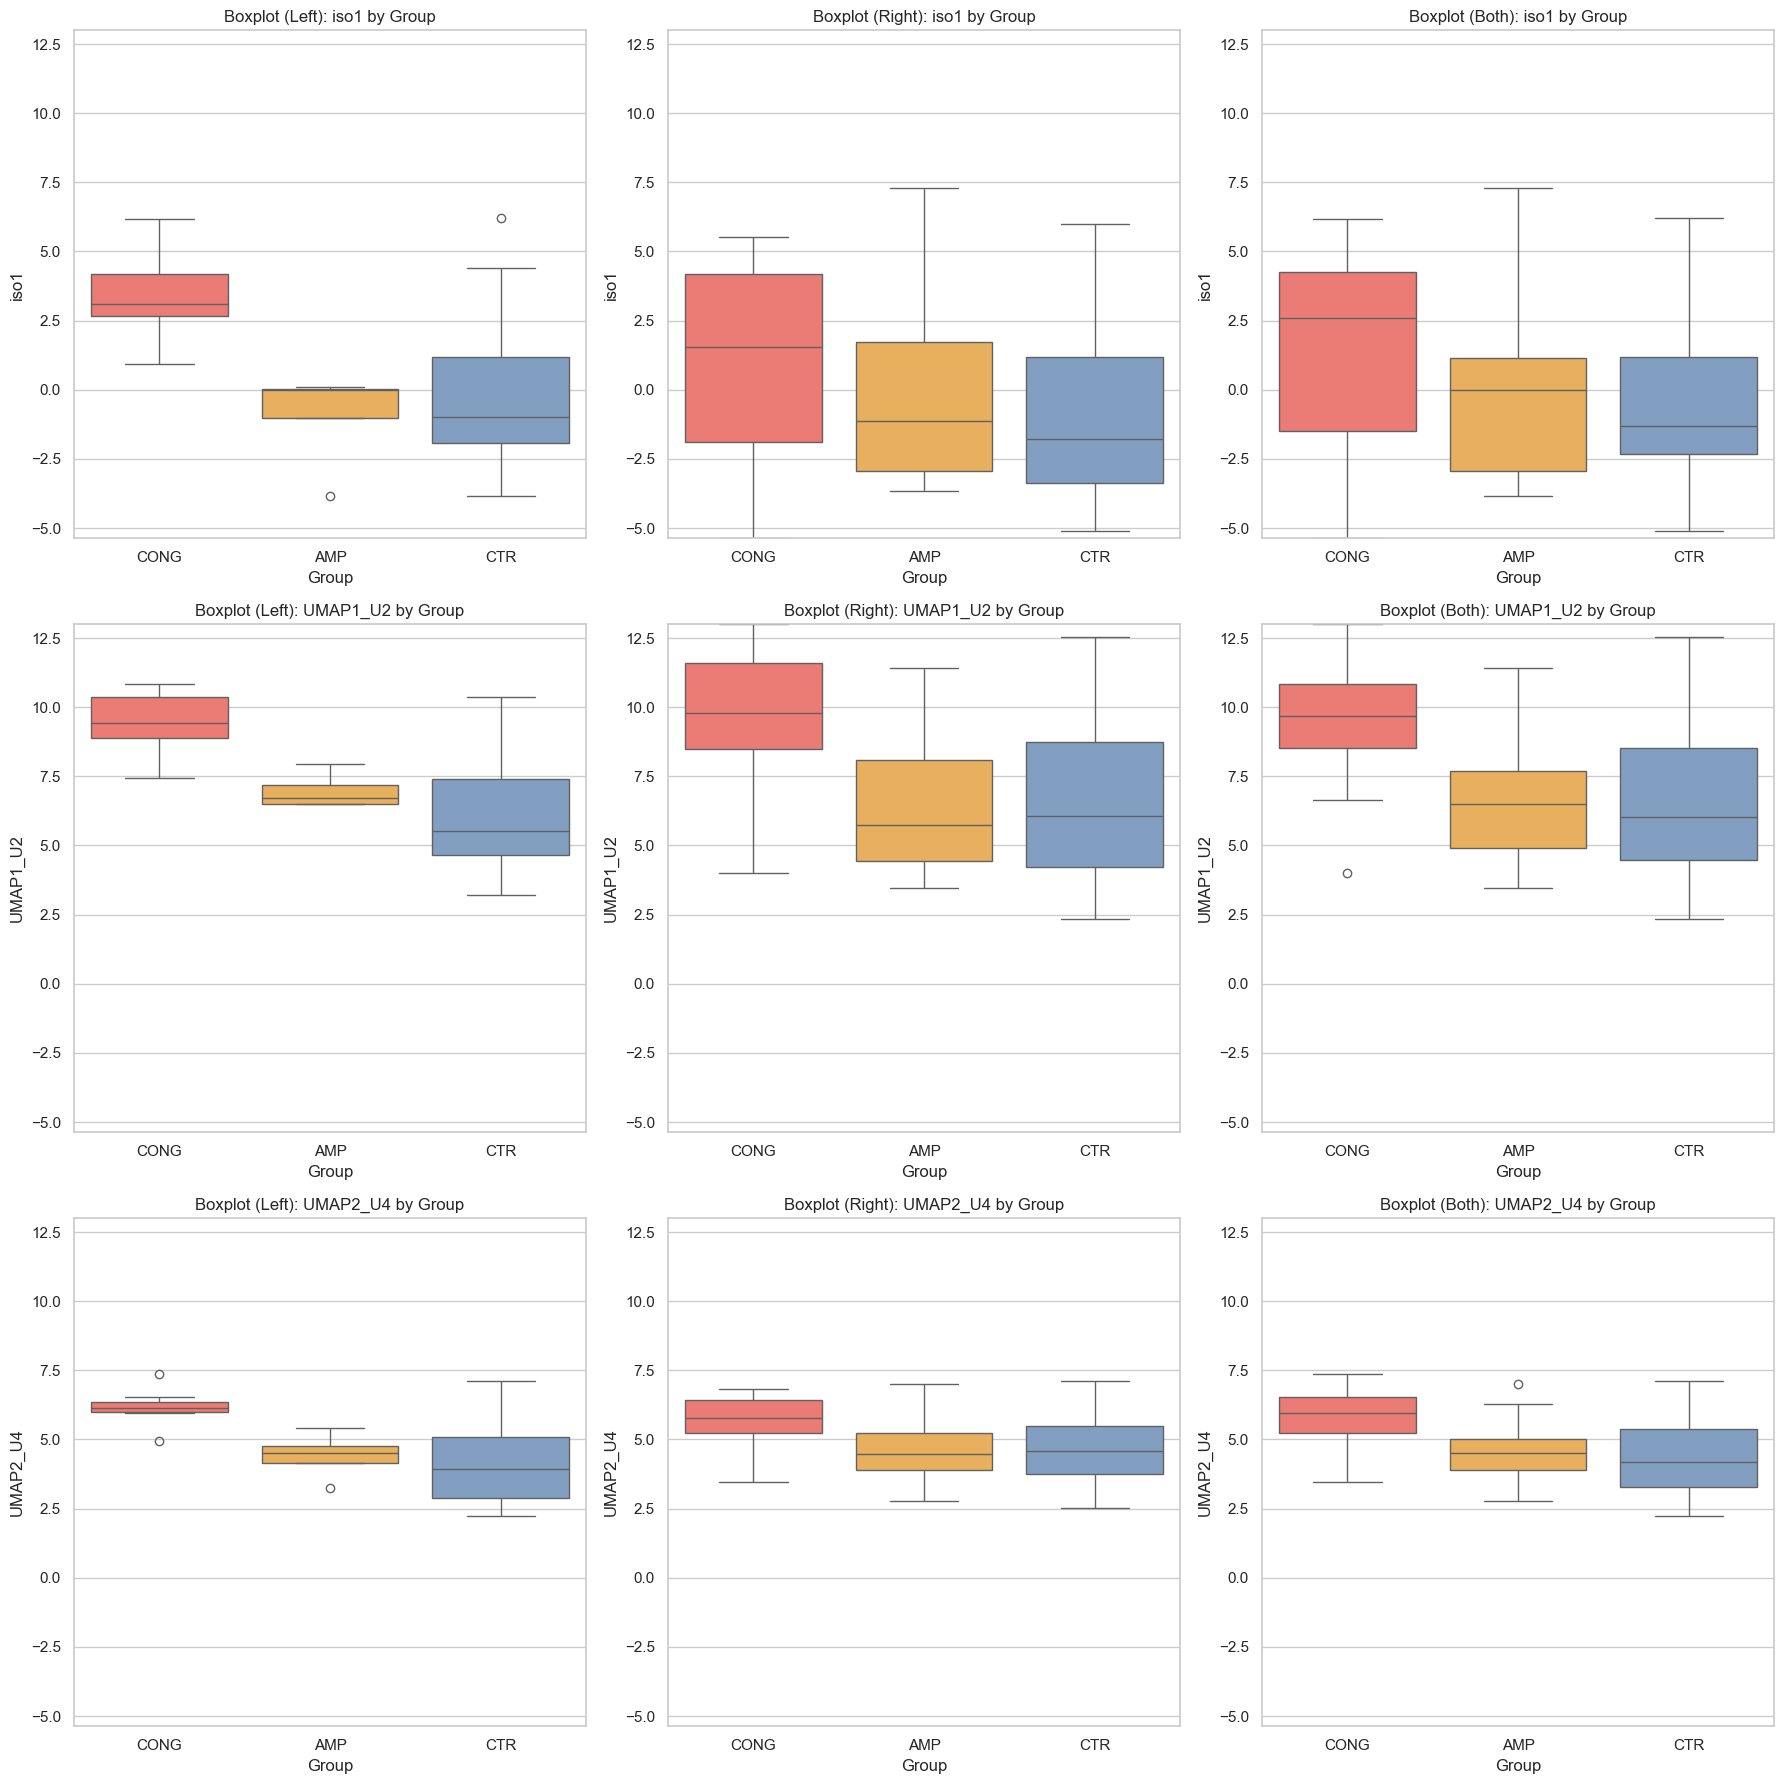

In [14]:
######################  compare 2024 and 2025 data, fix group order and color  ######################
####  Same as above, plus ALSO fix y-axis scale for easier comparison ####

# Replace green with a soft red
pastel_colors = sns.color_palette(["#ff6961", "#ffb347", "#779ecb"])  # soft red, soft orange, soft blue
group_colors = dict(zip(group_order, pastel_colors))

# Set style
sns.set(style="whitegrid")

# Create figure
fig, axes = plt.subplots(3, 3, figsize=(18, 18))

# List of shape measures
shape_measures = ['iso1', 'UMAP1_U2', 'UMAP2_U4']

# 1. Compute global y-limits across all measures and datasets
ymin = min(
    missing_hem_withControl_L[shape_measures].min().min(),
    missing_hem_withControl_R[shape_measures].min().min(),
    missing_hem_withControl[shape_measures].min().min()
)
ymax = max(
    missing_hem_withControl_L[shape_measures].max().max(),
    missing_hem_withControl_R[shape_measures].max().max(),
    missing_hem_withControl[shape_measures].max().max()
)

# 2. Loop through measures and plot
for i, shape in enumerate(shape_measures):
    # Left hemisphere
    sns.boxplot(
        x="Group", y=shape, data=missing_hem_withControl_L,
        order=group_order, palette=group_colors, ax=axes[i, 0]
    )
    axes[i, 0].set_title(f'Boxplot (Left): {shape} by Group')
    axes[i, 0].set_xlabel("Group")
    axes[i, 0].set_ylabel(shape)
    axes[i, 0].set_ylim(ymin, ymax)

    # Right hemisphere
    sns.boxplot(
        x="Group", y=shape, data=missing_hem_withControl_R,
        order=group_order, palette=group_colors, ax=axes[i, 1]
    )
    axes[i, 1].set_title(f'Boxplot (Right): {shape} by Group')
    axes[i, 1].set_xlabel("Group")
    axes[i, 1].set_ylabel(shape)
    axes[i, 1].set_ylim(ymin, ymax)

    # Both hemispheres
    sns.boxplot(
        x="Group", y=shape, data=missing_hem_withControl,
        order=group_order, palette=group_colors, ax=axes[i, 2]
    )
    axes[i, 2].set_title(f'Boxplot (Both): {shape} by Group')
    axes[i, 2].set_xlabel("Group")
    axes[i, 2].set_ylabel(shape)
    axes[i, 2].set_ylim(ymin, ymax)

# Layout
plt.tight_layout()
plt.show()


C:\Users\joyca\AppData\Local\Temp\ipykernel_1144\2991444638.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\joyca\AppData\Local\Temp\ipykernel_1144\2991444638.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\joyca\AppData\Local\Temp\ipykernel_1144\2991444638.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


C:\B_projWIP\proj_amputee\Analysis_2025\Plots\2024_GM_thickness_CSSyl_min_congAmpCtr_Box_L_R_Both.png


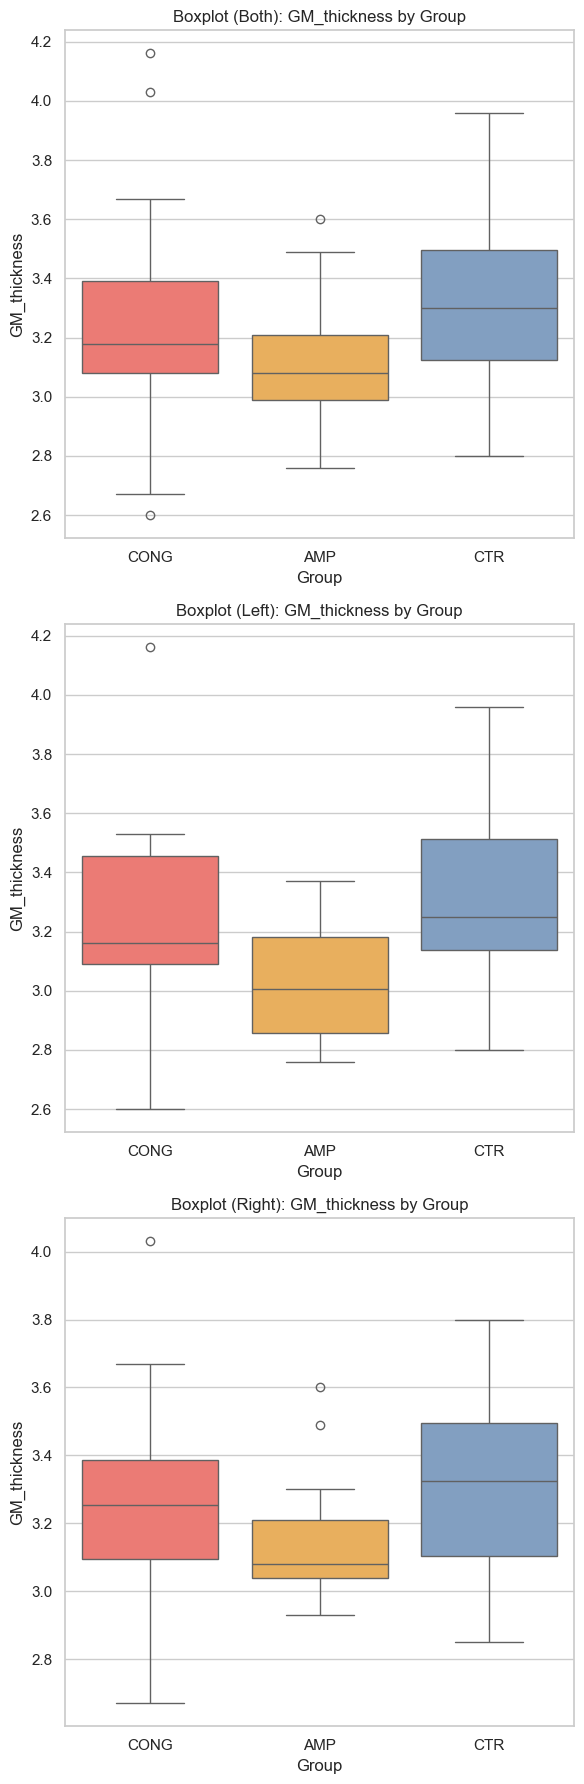

In [15]:
######################  compare 2024 and 2025 data, fix group order and color  ######################
######################  same as above, for one measure only, vertical instead of horizontal  ###################
#### Together, left hem, right hem  ####
####  ALSO fix y-axis scale for easier comparison  ####

# Define group order and color mapping
group_order = ["CONG", "AMP", "CTR"]

#sharp_colors = {"CONG": "green", "AMP": "orange", "CTR": "blue"}  # sharp green, sharp orange, sharp blue
#pastel_colors = sns.color_palette(["#77dd77", "#ffb347", "#779ecb"])  # soft green, soft orange, soft blue
pastel_colors = sns.color_palette(["#ff6961", "#ffb347", "#779ecb"])  # soft red, soft orange, soft blue

group_colors = dict(zip(group_order, pastel_colors))

# Set style
sns.set(style="whitegrid")

# Create figure
fig, axes = plt.subplots(3, 1, figsize=(6, 18))  # changed height to 6 for better layout

# Shape measure
shape = 'GM_thickness'

# Both hemispheres
sns.boxplot(
    x="Group", y=shape, data=missing_hem_withControl,
    order=group_order, palette=group_colors, ax=axes[0]
)
axes[0].set_title(f'Boxplot (Both): {shape} by Group')
axes[0].set_xlabel("Group")
axes[0].set_ylabel(shape)

# Left hemisphere
sns.boxplot(
    x="Group", y=shape, data=missing_hem_withControl_L,
    order=group_order, palette=group_colors, ax=axes[1]
)
axes[1].set_title(f'Boxplot (Left): {shape} by Group')
axes[1].set_xlabel("Group")
axes[1].set_ylabel(shape)

# Right hemisphere
sns.boxplot(
    x="Group", y=shape, data=missing_hem_withControl_R,
    order=group_order, palette=group_colors, ax=axes[2]
)
axes[2].set_title(f'Boxplot (Right): {shape} by Group')
axes[2].set_xlabel("Group")
axes[2].set_ylabel(shape)


# Layout
plt.tight_layout()


curPlotName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Analysis_2025\Plots\2024_{shape}_{curRegion}_{curDistType}_congAmpCtr_Box_L_R_Both.png'
print(curPlotName)
#plt.savefig(curPlotName)

plt.show()


C:\Users\joyca\AppData\Local\Temp\ipykernel_1144\1204845596.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\joyca\AppData\Local\Temp\ipykernel_1144\1204845596.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


C:\B_projWIP\proj_amputee\Analysis_2025\Plots\2024_UMAP1_U2_CSSyl_min_congAmpCtr_Box_L_R_magenta.png


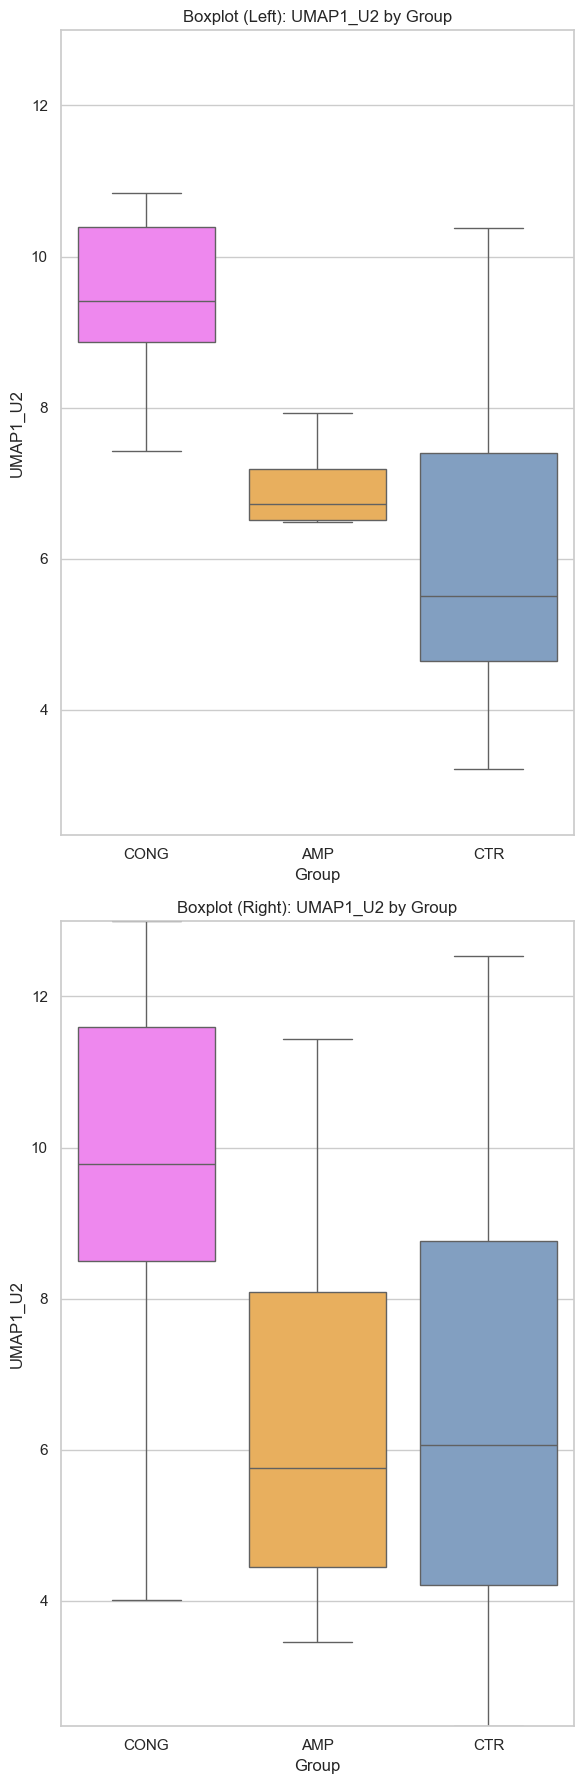

In [16]:
######################  compare 2024 and 2025 data, fix group order and color  ######################
######################  same as above, for one measure only, vertical instead of horizontal  ###################
####  left hem, right hem  ####
####  ALSO fix y-axis scale for easier comparison  ####

# Define group order and color mapping
group_order = ["CONG", "AMP", "CTR"]
#pastel_colors = sns.color_palette(["#ff6961", "#ffb347", "#779ecb"])  # soft red, soft orange, soft blue
pastel_colors = sns.color_palette(["#ff77ff", "#ffb347", "#779ecb"])  # soft magenta, soft orange, soft blue

group_colors = dict(zip(group_order, pastel_colors))

# Set style
sns.set(style="whitegrid")

# Create figure
fig, axes = plt.subplots(2, 1, figsize=(6, 18))  # vertical layout

# Shape measure
shape = 'UMAP1_U2'

# --- Compute global y-limits across Both, Left, Right ---
ymin = min(
    missing_hem_withControl[shape].min(),
    missing_hem_withControl_L[shape].min(),
    missing_hem_withControl_R[shape].min()
)
ymax = max(
    missing_hem_withControl[shape].max(),
    missing_hem_withControl_L[shape].max(),
    missing_hem_withControl_R[shape].max()
)
"""
# Both hemispheres
sns.boxplot(
    x="Group", y=shape, data=missing_hem_withControl,
    order=group_order, palette=group_colors, ax=axes[0]
)
axes[0].set_title(f'Boxplot (Both): {shape} by Group')
axes[0].set_xlabel("Group")
axes[0].set_ylabel(shape)
axes[0].set_ylim(ymin, ymax)
"""
# Left hemisphere
sns.boxplot(
    x="Group", y=shape, data=missing_hem_withControl_L,
    order=group_order, palette=group_colors, ax=axes[0]
)
axes[0].set_title(f'Boxplot (Left): {shape} by Group')
axes[0].set_xlabel("Group")
axes[0].set_ylabel(shape)
axes[0].set_ylim(ymin, ymax)

# Right hemisphere
sns.boxplot(
    x="Group", y=shape, data=missing_hem_withControl_R,
    order=group_order, palette=group_colors, ax=axes[1]
)
axes[1].set_title(f'Boxplot (Right): {shape} by Group')
axes[1].set_xlabel("Group")
axes[1].set_ylabel(shape)
axes[1].set_ylim(ymin, ymax)

# Layout
plt.tight_layout()

curPlotName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Analysis_2025\Plots\2024_{shape}_{curRegion}_{curDistType}_congAmpCtr_Box_L_R_magenta.png'
#curPlotName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Analysis_2025\Plots\2024_{shape}_{curRegion}_{curDistType}_congAmpCtr_Box_L_R_Both.png'
print(curPlotName)
#plt.savefig(curPlotName)

plt.show()


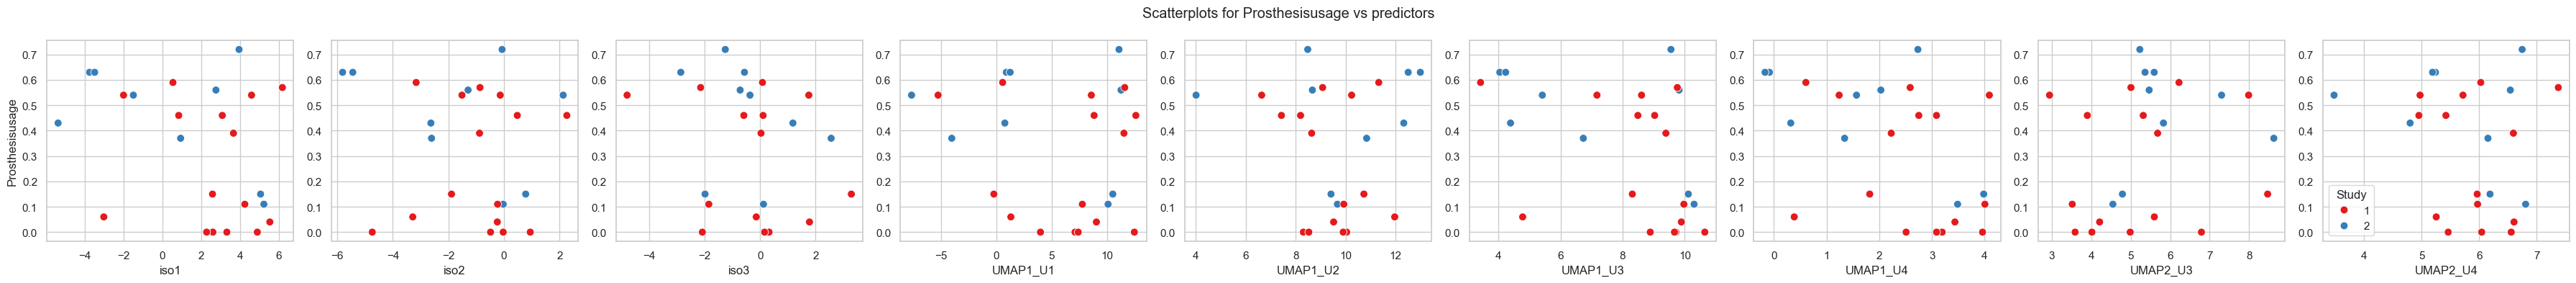

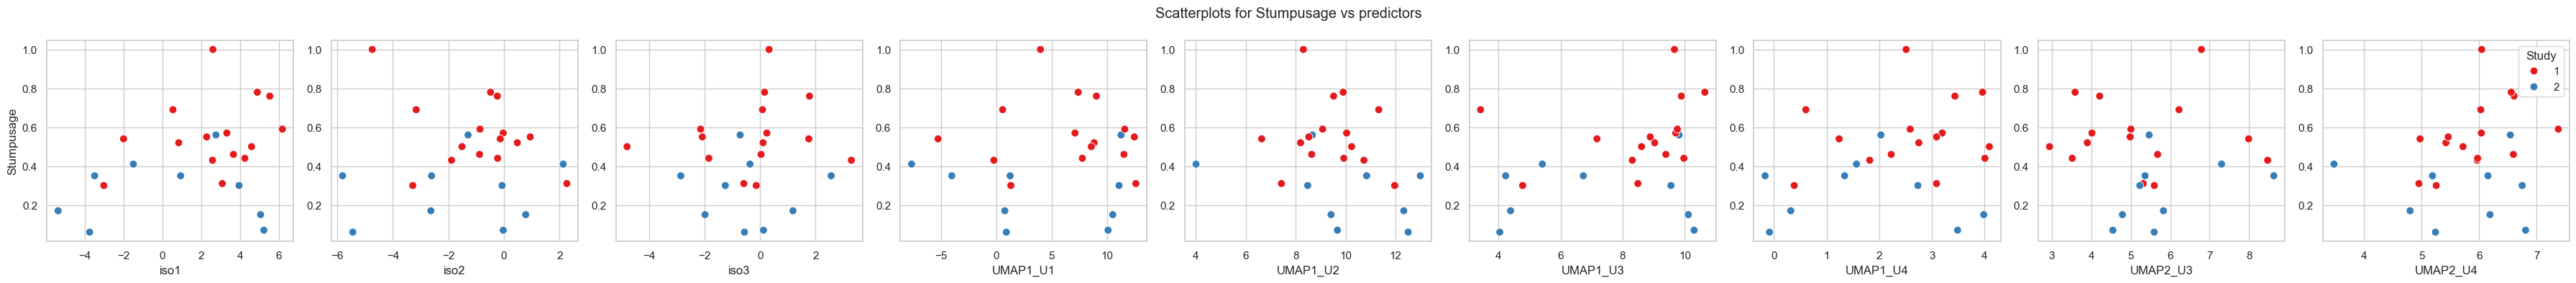

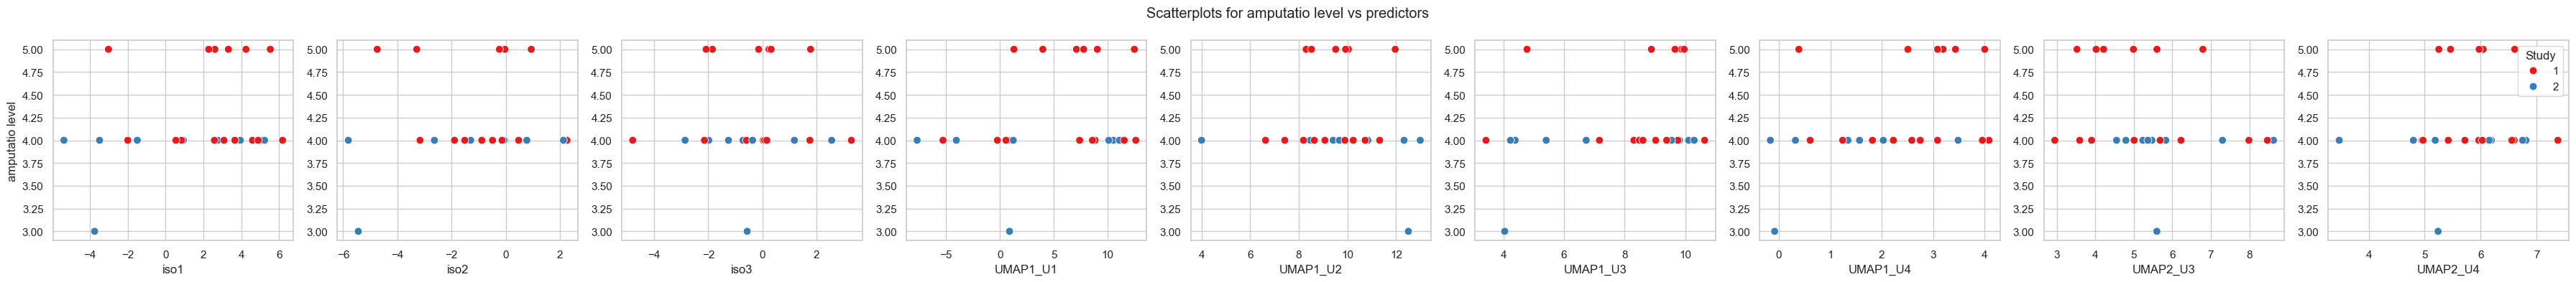

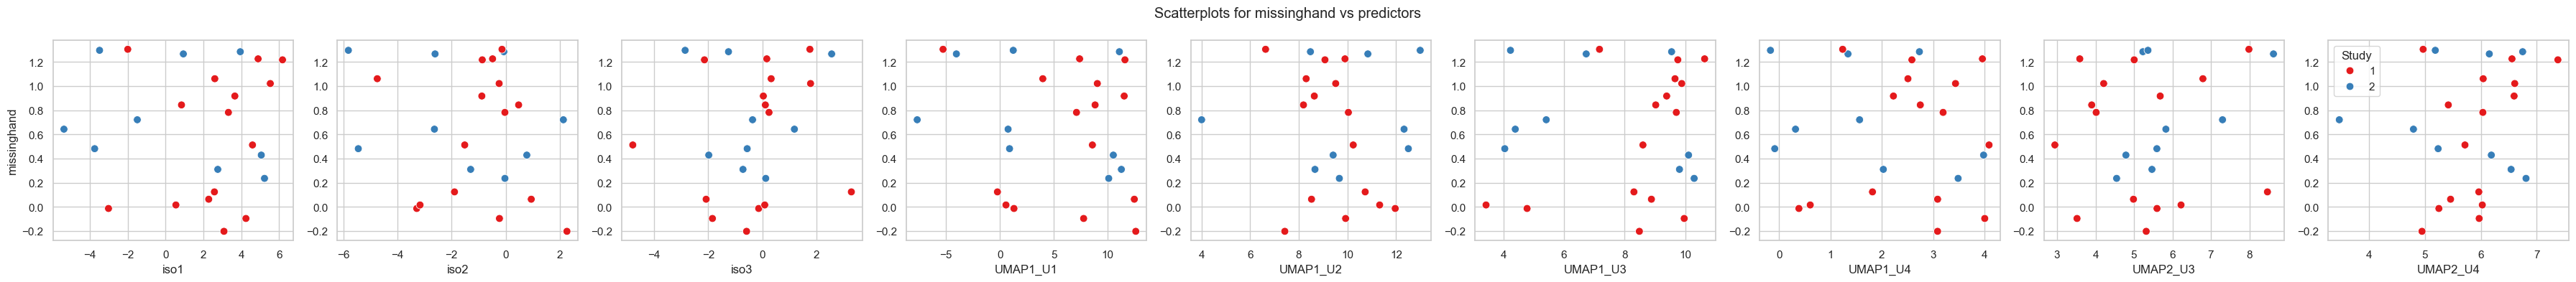

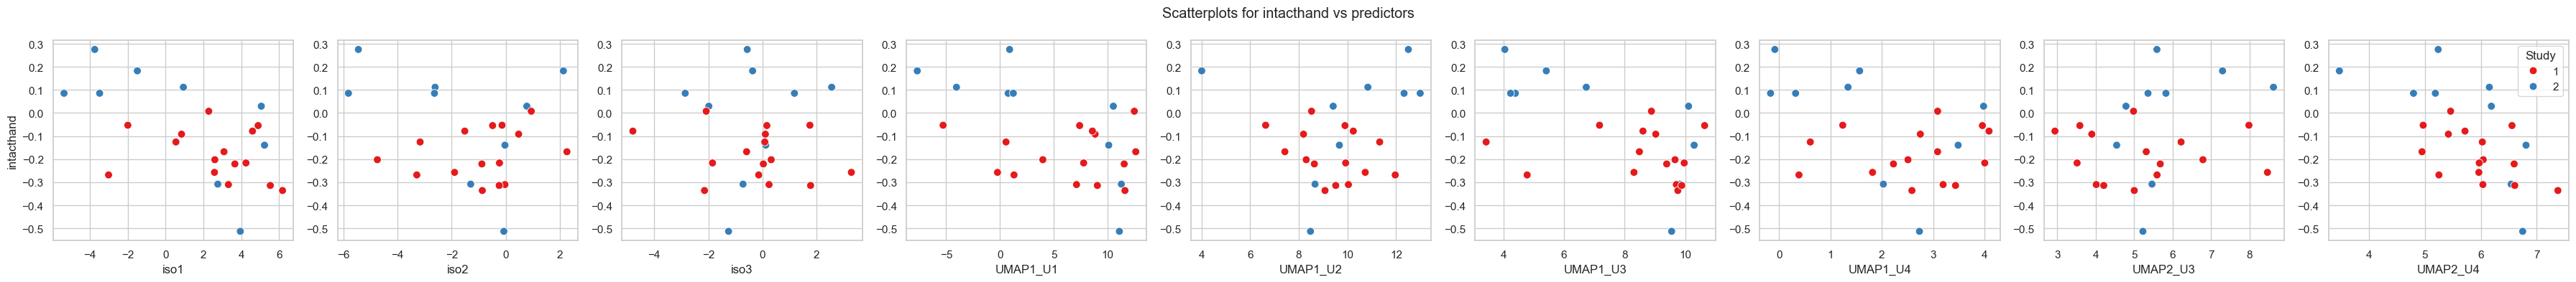

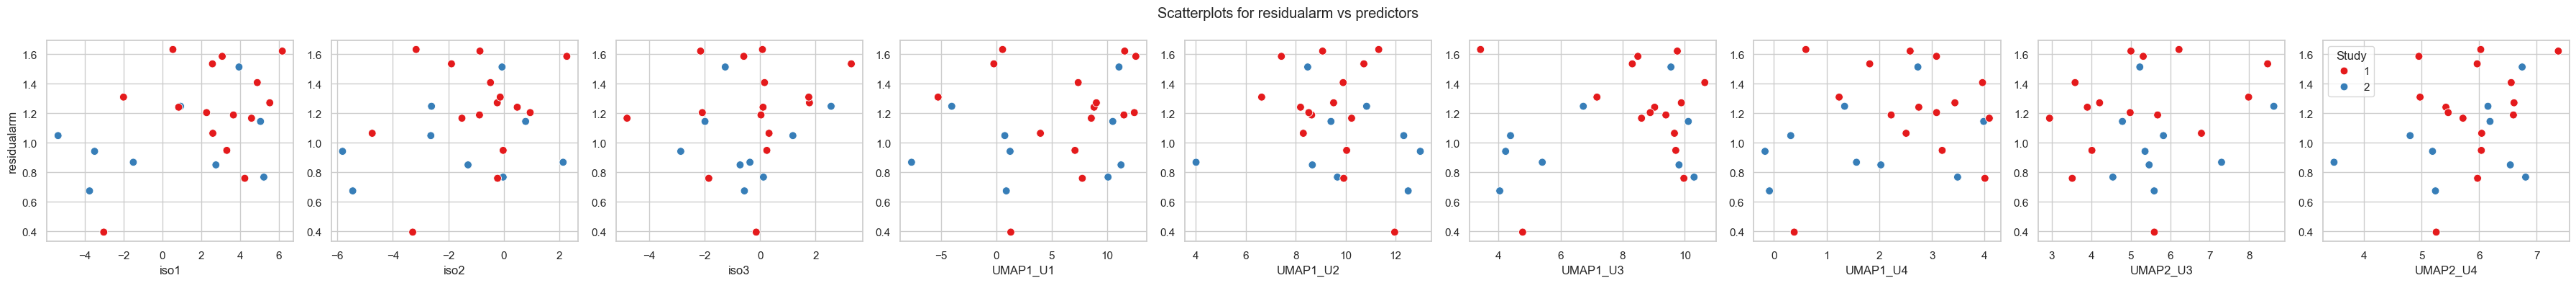

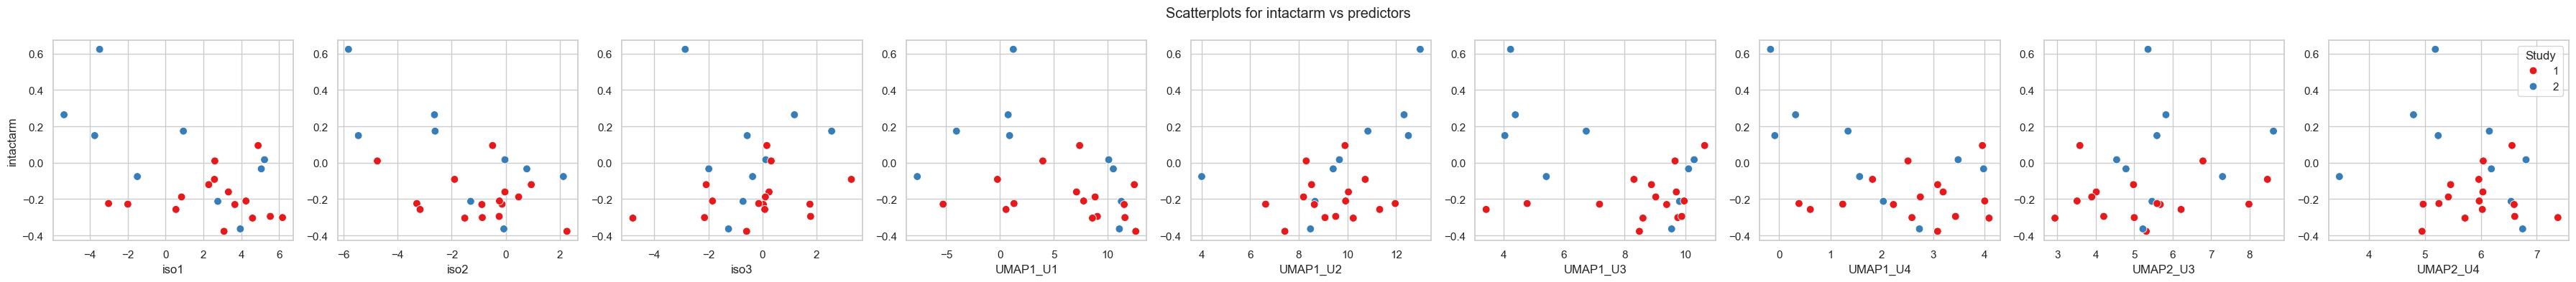

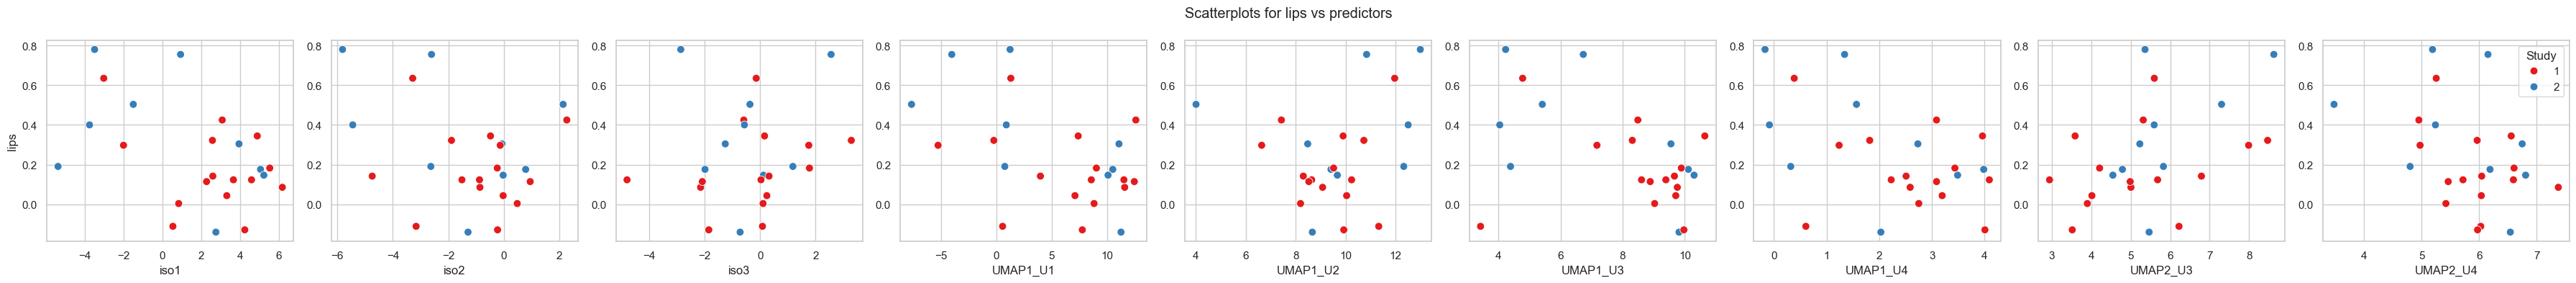

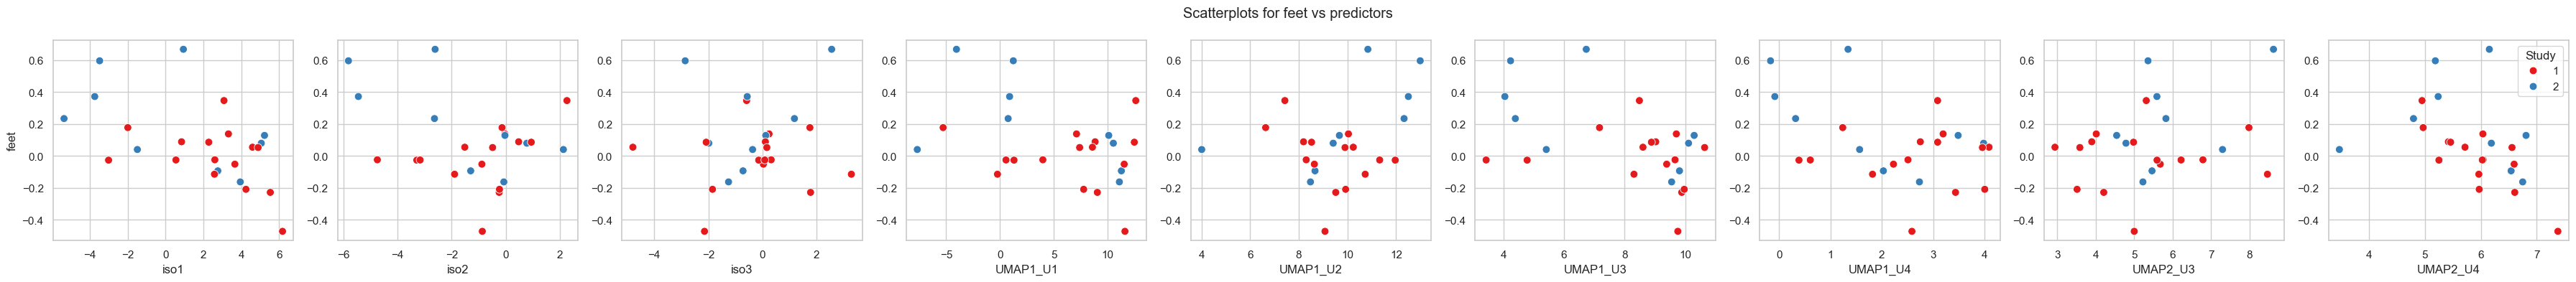

In [17]:
################################	Scatterplots by Study  #################################
# Check for:
# Group differences – color (hue) lets you see if trends differ between studies/groups.
# Linearity – do points roughly form a straight line? → Indicates whether a linear model might be reasonable.
# Direction – positive or negative trend.
# Strength of association – how tightly points cluster around a trend.
# Outliers – points that are far from the general trend.
# Heteroscedasticity – do the spreads of points change along the x-axis?

predictors = ['iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2', 'UMAP1_U3', 'UMAP1_U4','UMAP2_U3','UMAP2_U4']     
responses = ['Prosthesisusage','Stumpusage','amputatio level', 'missinghand','intacthand','residualarm','intactarm','lips','feet']   

for y_var in responses:
    plt.figure(figsize=(len(predictors)*4, 4))  # width scales with number of predictors
    for i, x_var in enumerate(predictors, 1):
        plt.subplot(1, len(predictors), i)
        sns.scatterplot(
            data=cur_info,
            x=x_var,
            y=y_var,
            hue='Study',
            palette='Set1',
            s=60
        )
        plt.xlabel(x_var)
        plt.ylabel(y_var if i == 1 else '')  # label only first subplot
        if i != len(predictors):
            plt.legend([],[], frameon=False)  # remove extra legends
    plt.suptitle(f'Scatterplots for {y_var} vs predictors')
    plt.tight_layout()
    plt.show()


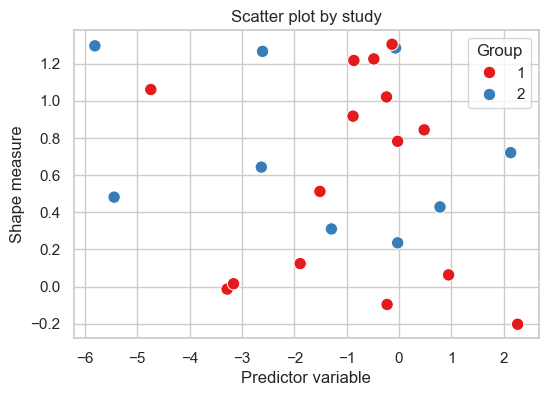

In [18]:
##	Scatterplots, colors by study, one group only  ##

plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=cur_info,
    x='iso2',
    y='missinghand',
    hue='Study',         # Color by group
    palette='Set1',      # Color palette
    s=80                 # Point size
)

plt.xlabel('Predictor variable')
plt.ylabel('Shape measure')
plt.title('Scatter plot by study')
plt.legend(title='Group')
plt.show()

##############  Scatter plots: visual check of linearity, direction, and outliers  ###############
# For each scatterplot:
# Linearity: Do the points roughly follow a straight line? This helps decide if a linear model is reasonable.
# Direction of association: Positive or negative correlation.
# Strength: Are the points tightly clustered around a trend or very scattered?
# Outliers: Points that deviate strongly from the trend.
# Heteroscedasticity: Does the spread of points change along the x-axis? This affects assumptions for linear regression.

predictors = ['iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2', 'UMAP1_U3', 'UMAP1_U4','UMAP2_U3','UMAP2_U4']
responses = ['Prosthesisusage','Stumpusage','amputatio level', 'missinghand','intacthand','residualarm','intactarm','lips','feet']   

# Create scatterplots for each predictor-response pair
for resp in responses:
    sns.pairplot(cur_info, x_vars=predictors, y_vars=[resp], height=2.5)
    plt.suptitle(f'Scatterplots for response {resp}', y=1.02)
    plt.show()

C:\B_projWIP\proj_amputee\Analysis_2025\Plots\2024_CSSyl_min_usingHem_onlyCong_heatmap.png


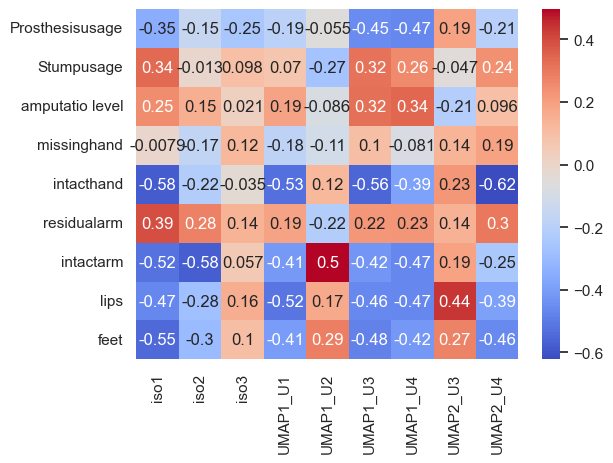

In [20]:
##########  Heatmap of correlations: shows all 7 × 4 predictor-response correlations numerically  ##########
# for a quick summary of strength and direction
predictors = ['iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2', 'UMAP1_U3', 'UMAP1_U4','UMAP2_U3','UMAP2_U4']
responses = ['Prosthesisusage','Stumpusage','amputatio level', 'missinghand','intacthand','residualarm','intactarm','lips','feet']   
#responses = ['Stumpusage', 'missinghand','intacthand']   


corr_matrix = cur_info[predictors + responses].corr().loc[responses, predictors]
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

curPlotName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Analysis_2025\Plots\2024_{curRegion}_{curDistType}_usingHem_onlyCong_heatmap.png'
print(curPlotName)
plt.tight_layout()
#plt.savefig(curPlotName)

plt.show()

C:\Users\joyca\AppData\Local\Temp\ipykernel_1144\1200930156.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\joyca\AppData\Local\Temp\ipykernel_1144\1200930156.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\joyca\AppData\Local\Temp\ipykernel_1144\1200930156.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\joyca\AppData\Local\Temp\ipykernel_1144\1200930156.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

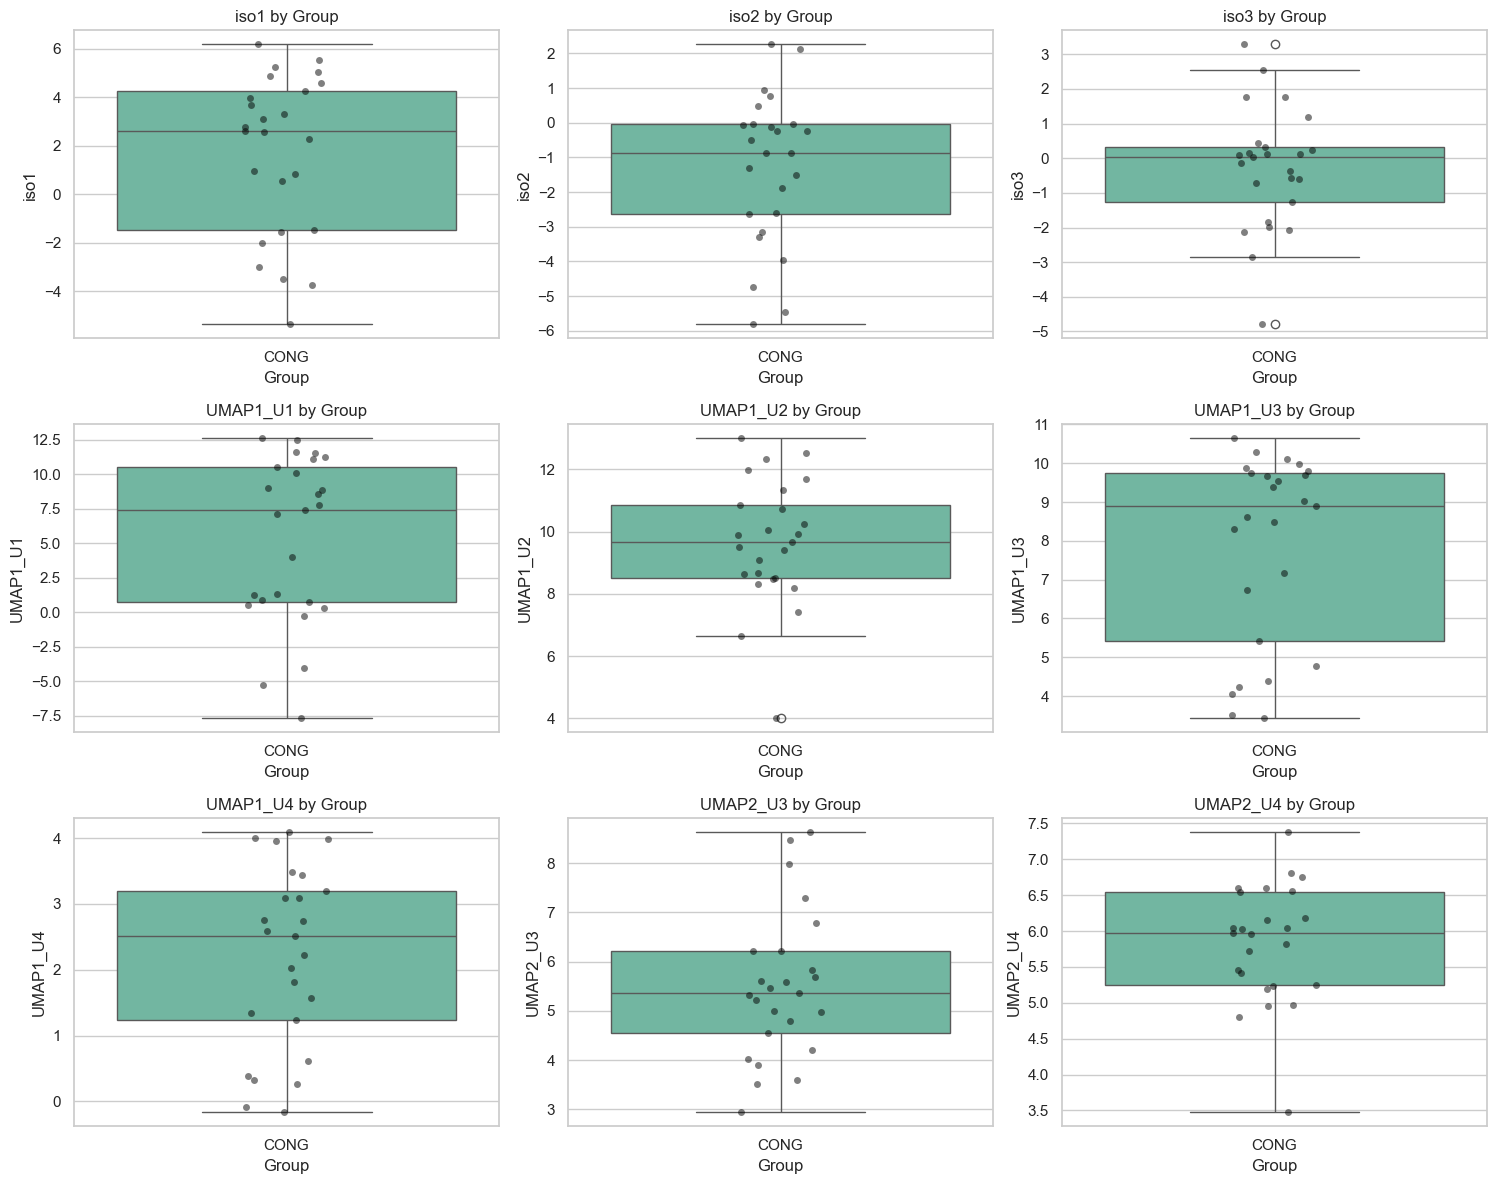

In [21]:
########################	Boxplots: for categorical predictors → group distributions    #########################

# Group differences: Are the medians different between groups?
#                    Are the interquartile ranges overlapping or separated?
# Spread and variability: Are some groups more variable than others?
# Outliers: Points outside the whiskers indicate extreme values.
# Symmetry / skewness: Check if distributions are symmetric or skewed.
# Potential for further analysis: If distributions look very different between groups → ANOVA/linear model might detect differences.
#                                 If distributions are highly non-normal → consider non-parametric tests.

shape_measures = ['iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2', 'UMAP1_U3', 'UMAP1_U4', 'UMAP2_U3', 'UMAP2_U4']
group_col = 'Group'

# Set grid dimensions
n_cols = 3
n_rows = -(-len(shape_measures) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()  # make it easy to loop

for i, measure in enumerate(shape_measures):
    ax = axes[i]
    sns.boxplot(
        data=cur_info,
        x=group_col,
        y=measure,
        palette='Set2',
        ax=ax
    )
    sns.stripplot(
        data=cur_info,
        x=group_col,
        y=measure,
        color='black',
        alpha=0.5,
        jitter=True,
        ax=ax
    )
    ax.set_title(f'{measure} by Group')
    ax.set_xlabel('Group')
    ax.set_ylabel(measure)

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


C:\B_projWIP\proj_amputee\Analysis_2025\Plots\iso1_CSSyl_min_ctr_amp_cong_Box_Distribution.png


C:\Users\joyca\AppData\Local\Temp\ipykernel_1144\1096258555.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


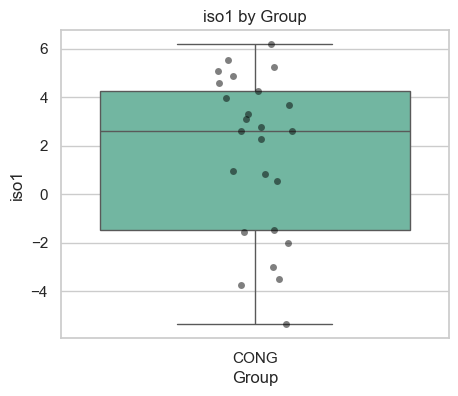

In [22]:
#####################  Boxplot, one group only  #####################
measure = 'iso1'      # <-- choose the measure you want
group_col = 'Group'

plt.figure(figsize=(5, 4))
sns.boxplot(
    data=cur_info,
    x=group_col,
    y=measure,
    palette='Set2'
)
sns.stripplot(
    data=cur_info,
    x=group_col,
    y=measure,
    color='black',
    alpha=0.5,
    jitter=True
)
plt.title(f'{measure} by Group')
plt.xlabel('Group')
plt.ylabel(measure)

curPlotName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Analysis_2025\Plots\{measure}_{curRegion}_{curDistType}_ctr_amp_cong_Box_Distribution.png'
print(curPlotName)
#plt.savefig(curPlotName)

plt.show()


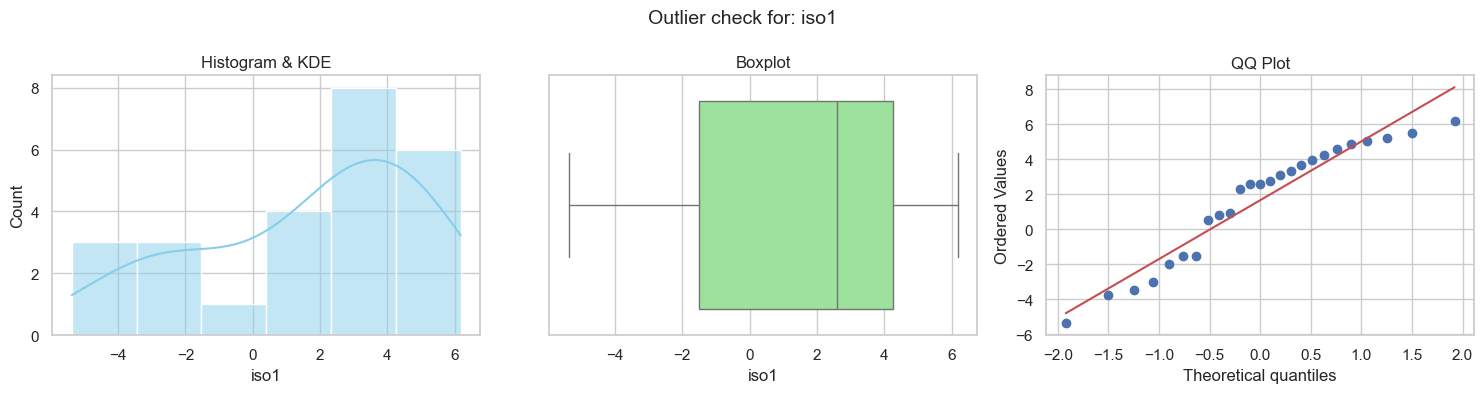

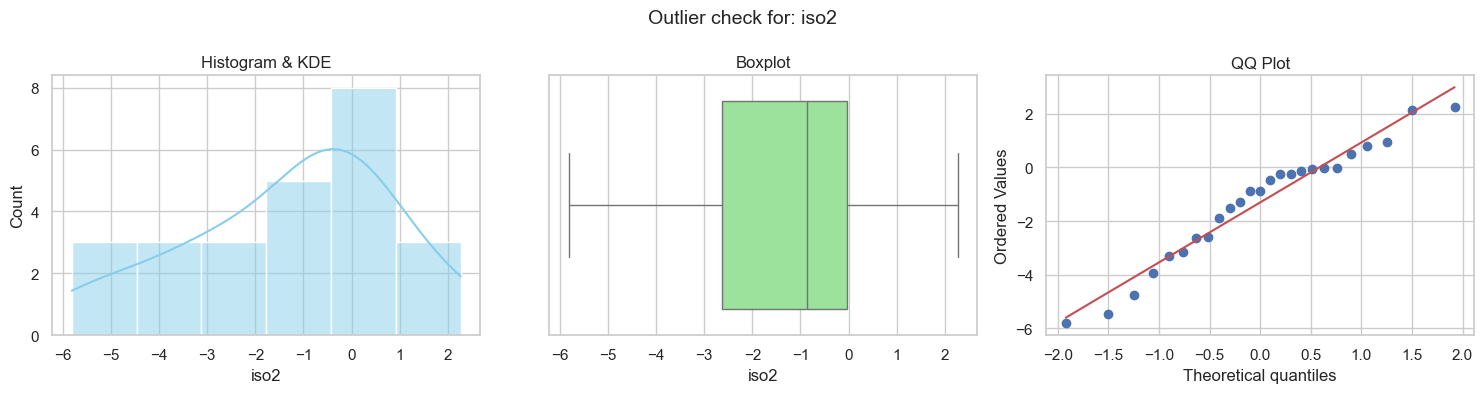

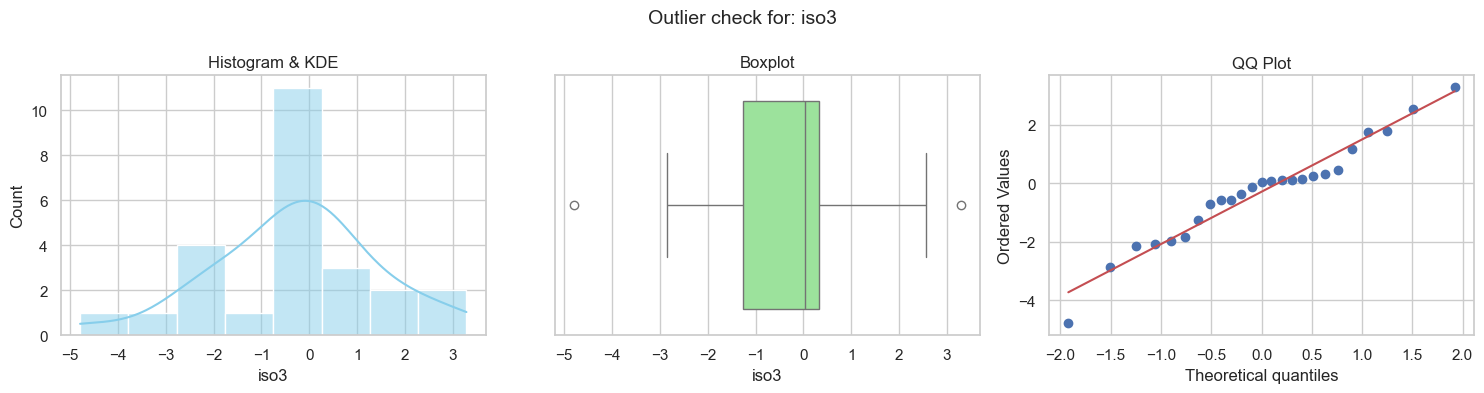

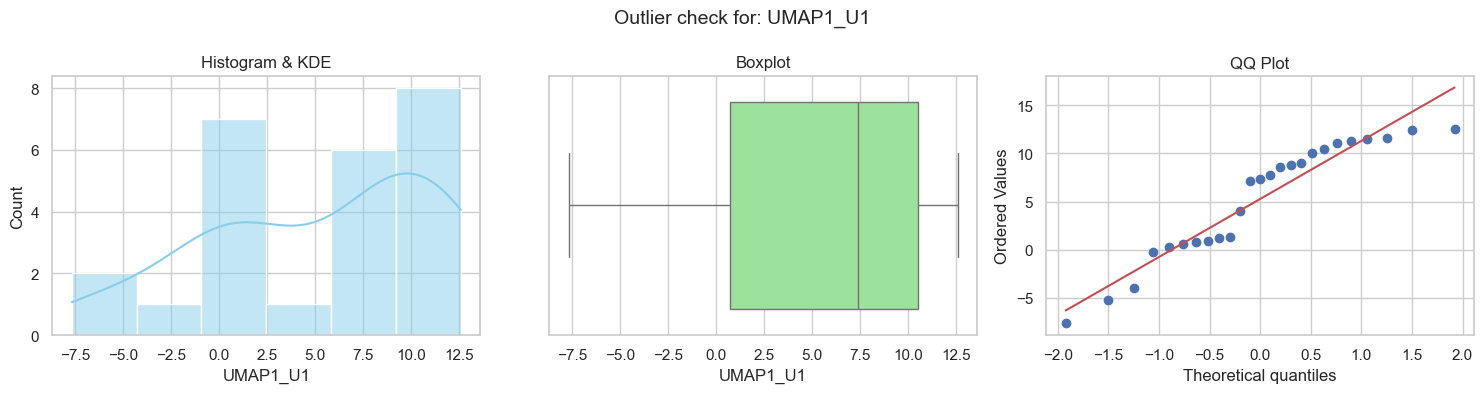

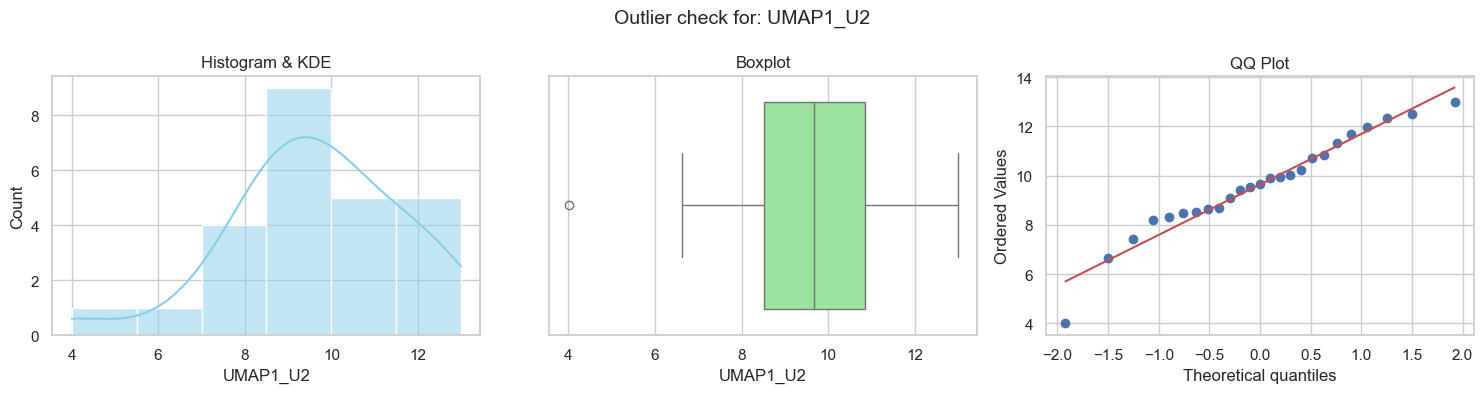

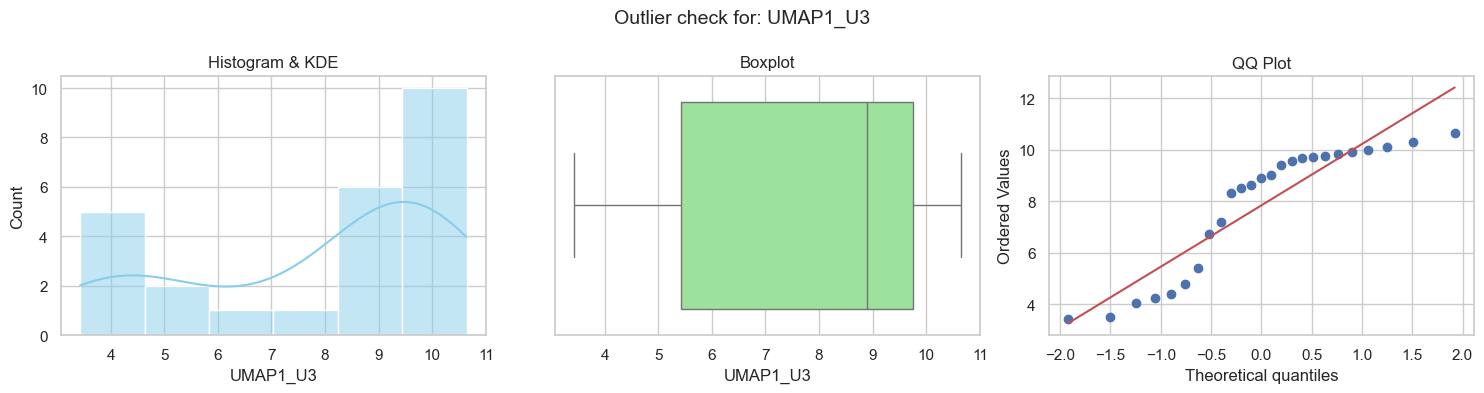

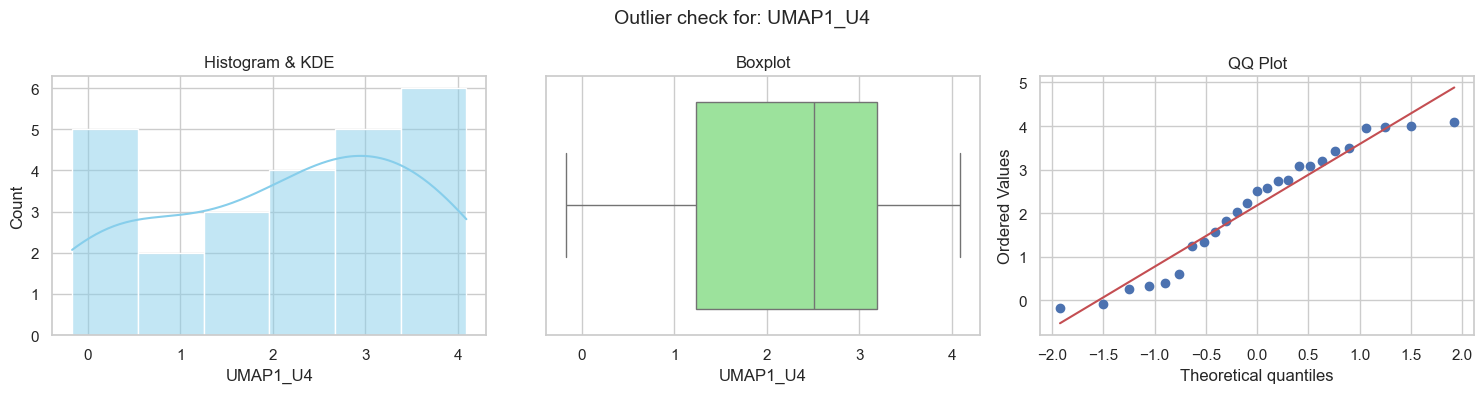

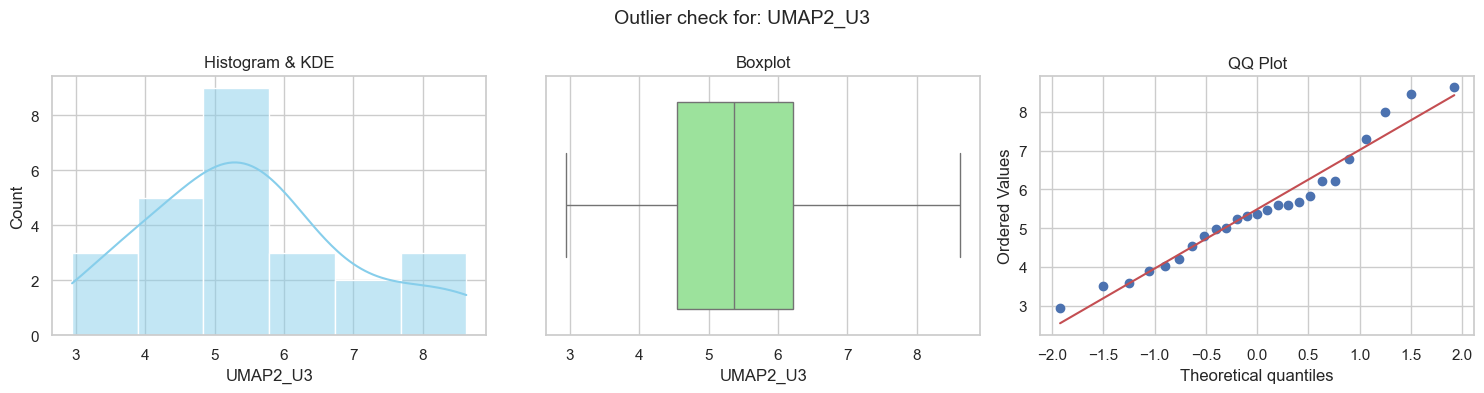

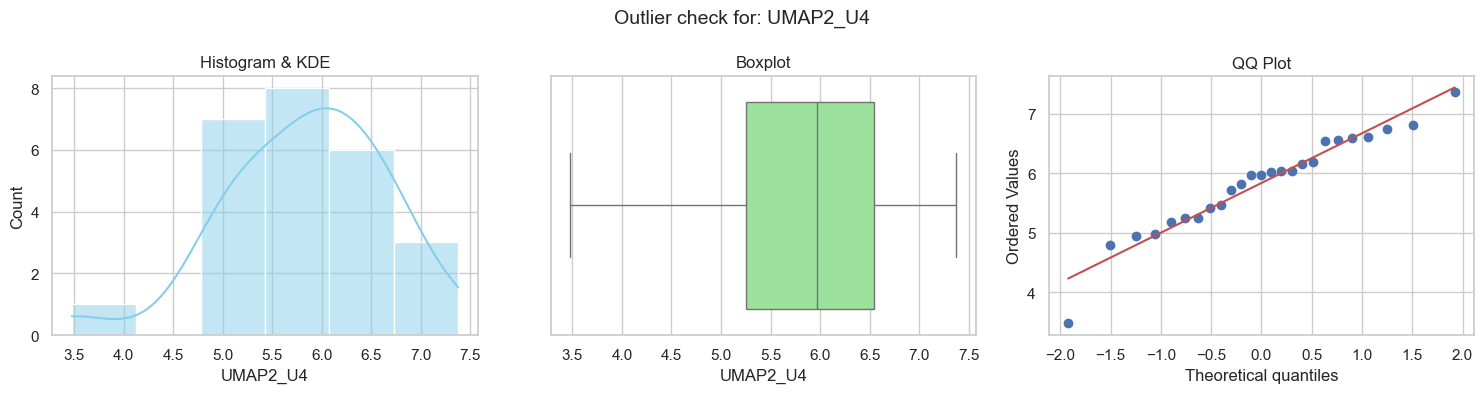

In [23]:
######################	Identify obvious outliers or impossible values  #########################
# Histogram + KDE (Kernel Density Estimate, basically a smoothed version of a histogram) → see distribution & distant bars.
# Boxplot → spot extreme points visually.
# QQ Plot → check normality and tail outliers.
#           Points on the diagonal → data matches the distribution.
#           Deviations at the extremities (tails) → you have heavy tails, skewness, or possible outliers.
#           A few extreme points far from the line = potential point outliers.
#           Smooth but consistent deviation (e.g., curve shape) = variable is just not normally distributed.
    
import scipy.stats as stats

# Example: use your dataframe here
df = cur_info.copy()

# List of numeric columns to check
numeric_cols = [
    'iso1', 'iso2', 'iso3',
    'UMAP1_U1', 'UMAP1_U2', 'UMAP1_U3', 'UMAP1_U4',
    'UMAP2_U3', 'UMAP2_U4'
]

# Loop through each column and make a 1-row, 3-plot dashboard
for col in numeric_cols:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'Outlier check for: {col}', fontsize=14)

    # 1. Histogram + KDE
    sns.histplot(df[col], kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title("Histogram & KDE")
    
    # 2. Boxplot
    sns.boxplot(x=df[col], ax=axes[1], color='lightgreen')
    axes[1].set_title("Boxplot")
    
    # 3. QQ Plot
    stats.probplot(df[col].dropna(), dist="norm", plot=axes[2])
    axes[2].set_title("QQ Plot")

    plt.tight_layout()
    plt.show()


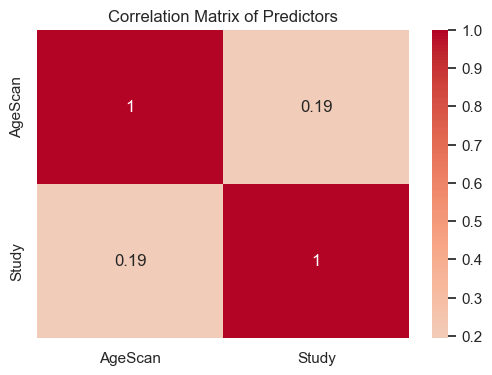

In [24]:
###########################	Check if predictors are correlated (multicollinearity risk)  ###############################
# Use correlation heatmap for numeric predictors.
# High correlations (>|0.8|) between predictors suggest redundancy → multicollinearity risk.

# Select only numeric predictors
numeric_cols = cur_info[['AgeScan', 'Study']]

# Compute correlation matrix
corr = numeric_cols.corr()

# Plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Predictors")
plt.show()

In [25]:
# Use VIF test after dummy-coding categorical variables for full set.
# Select predictors and covariates
# VIF > 5 → moderate multicollinearity concern.
# VIF > 10 → serious multicollinearity, consider dropping/redefining predictors.

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select predictors
predictors = ['AgeScan', 'Gender', 'Study', 'Hemisphere']
X = cur_info[predictors]

# One-hot encode categoricals (drop_first avoids dummy trap)
X_enc = pd.get_dummies(X, drop_first=True)

# Ensure numeric dtype
X_enc = X_enc.astype(float)

# Add constant
X_enc = sm.add_constant(X_enc)

# Compute VIF
vif = pd.DataFrame()
vif["Variable"] = X_enc.columns
vif["VIF"] = [variance_inflation_factor(X_enc.values, i) for i in range(X_enc.shape[1])]

print(vif)


           Variable        VIF
0             const  21.905488
1           AgeScan   1.050805
2             Study   1.073300
3          Gender_M   1.084578
4  Hemisphere_Right   1.090123


In [26]:
# Check correlation between AgeScan and Study
corr = cur_info[['AgeScan', 'Study']].corr()
print(corr)

          AgeScan     Study
AgeScan  1.000000  0.194616
Study    0.194616  1.000000
